# 03. Modeling & Evaluation (Regression)
- 타깃: `log10(cycle_life)` → 예측 후 `10^` 역변환하여 사이클 단위 **MAPE** 로 평가
- **Batch 1 → Train / Valid(Hold-out)**, **Batch 2 → Test**, **Batch 3 → 추가 Test** (Batch 2·3 모두 모델 선택에 사용하지 않음)
- 검증은 **충전 정책(프로토콜) 단위 분리**: 같은 정책의 셀이 Train 과 Valid 에 동시에 들어가지 않도록 함

> 실행: `python -m src.train --eval-batches 2 3` 와 동일한 결과를 단계별로 보여 줍니다. Batch 2·3 은 모델 선택에 쓰지 않고 선택이 끝난 뒤 평가에만 사용했습니다.

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # 저장소 루트 (src/ 임포트용)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
for f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if f in {x.name for x in fm.fontManager.ttflist}: plt.rcParams["font.family"] = f; break
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
ROOT = Path.cwd().parent; FIG = ROOT / "results" / "figures"

In [2]:
from src.train import load_data, compare_models, FEATURE_SETS, STAGES
from src.validation import group_holdout
df = load_data(ROOT / "data"); b1 = df[df.batch == 1].reset_index(drop=True)
tr_i, va_i, chosen = group_holdout(b1, 42)
TR, VA = b1.loc[tr_i].reset_index(drop=True), b1.loc[va_i].reset_index(drop=True)
assert set(TR.policy).isdisjoint(VA.policy)
print(f"Batch1 {len(b1)}셀 / 정책 {b1.policy.nunique()}개  →  Train {len(TR)}셀 ({TR.policy.nunique()}정책), Valid {len(VA)}셀 ({VA.policy.nunique()}정책)")
print("Valid 정책:", chosen); print("Valid 수명:", sorted(VA.cycle_life.astype(int))); print("Train 수명 범위:", int(TR.cycle_life.min()), "~", int(TR.cycle_life.max()))

Batch1 36셀 / 정책 20개  →  Train 29셀 (16정책), Valid 7셀 (4정책)
Valid 정책: ['6C(40%)-3C', '4.8C(80%)-4.8C', '5.4C(40%)-3.6C', '7C(40%)-3.6C']
Valid 수명: [617, 625, 636, 854, 870, 1017, 1054]
Train 수명 범위: 534 ~ 1074


## 1. 검증 설계 변경 근거 (Day 1 → Day 2): 랜덤 CV vs 정책 단위 CV
Batch 1 은 정책 22개 × 셀 1~3개 구조입니다. 셀 단위 랜덤 분할은 같은 정책의 형제 셀을 학습에서 보여 줍니다. 같은 모델·피처로 두 방식을 비교합니다.

,featset,model,n_feat,CV_group,CV_group_sd,CV_random,CV_random_sd,CV_extrap,score_stage2,Valid
0,D6 dQ4+QD2+QDmax,ElasticNet,6,5.500,1.400,5.200,1.400,6.800,6.100,7.500
1,D6 dQ4+QD2+QDmax,Ridge,6,5.600,1.400,5.300,1.400,6.300,6.000,7.500
2,D6 dQ4+QD2+QDmax,Linear,6,5.700,1.800,5.400,1.400,6.900,6.300,7.700
3,D6 dQ4+QD2+QDmax,GPR,6,6.500,3.500,5.500,1.400,12.300,9.400,8.000
4,D6 dQ4+QD2+QDmax,PLS(2),6,7.200,2.700,6.200,2.300,13.000,10.100,8.500
5,D4 dQ4,Linear,4,8.300,2.100,8.000,2.500,14.000,11.100,9.200
6,V2 var+min,PLS(2),2,8.300,1.900,7.800,2.300,15.000,11.700,8.700
7,V2 var+min,Linear,2,8.300,1.900,7.800,2.300,15.000,11.700,8.700
8,D4 dQ4,ElasticNet,4,8.700,2.000,8.300,2.400,15.600,12.100,9.200
9,V2 var+min,ElasticNet,2,8.700,2.000,8.200,2.600,15.000,11.800,8.800


정책 단위 CV 가 랜덤 CV 보다 나쁜 조합: 27/27, 평균 차이 0.9%p


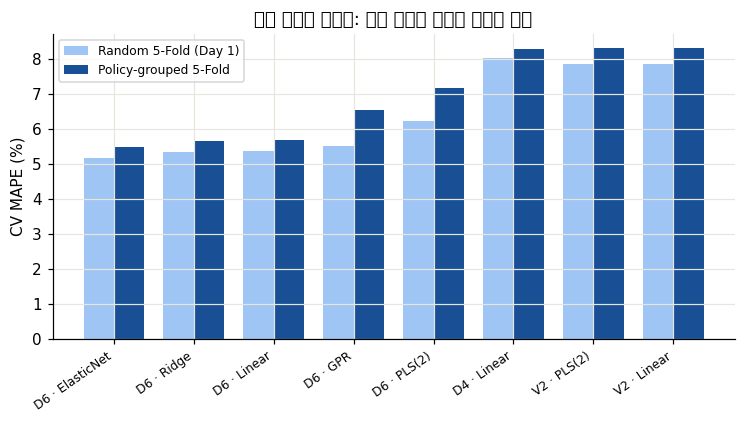

In [3]:
cv = compare_models(TR, VA).sort_values("CV_group").reset_index(drop=True)
display(cv.round(1))
gap = (cv.CV_group - cv.CV_random)
print(f"정책 단위 CV 가 랜덤 CV 보다 나쁜 조합: {(gap > 0).sum()}/{len(cv)}, 평균 차이 {gap.mean():.1f}%p")
top = cv.head(8); lab = top.featset.str.split().str[0] + " · " + top.model
fig, ax = plt.subplots(figsize=(8, 3.6)); x = np.arange(len(top)); w = .38
ax.bar(x - w/2, top.CV_random, w, color="#9ec5f4", label="Random 5-Fold (Day 1)"); ax.bar(x + w/2, top.CV_group, w, color="#184f95", label="Policy-grouped 5-Fold")
ax.set_xticks(x, lab, rotation=35, ha="right", fontsize=8); ax.set_ylabel("CV MAPE (%)"); ax.legend(fontsize=8); ax.set_title("랜덤 분할은 낙관적: 정책 단위로 나누면 오차가 커짐")
fig.savefig(FIG / "cv_random_vs_group.png", dpi=180, bbox_inches="tight"); plt.show()

## 2. 모델 선택 (Train 안에서만)
- **1차 (사전 확정)**: 정책 단위 CV MAPE 최소
- **개선 단계**: Test 결과를 본 뒤, Batch 1 안에서만 **외삽 CV**(수명이 가장 짧은 정책 20·25·30% 를 검증으로) 를 설계하고 `(정책 단위 CV + 외삽 CV)/2` 최소로 재선택. 선택 규칙은 외삽 CV 값을 보기 전에 고정함.

In [4]:
for s, (label, key) in STAGES.items():
    b = cv.sort_values(key).iloc[0]
    print(f"{label:26s} 기준={key:13s} → {b.featset} / {b.model}   CV_group={b.CV_group:.1f}  CV_extrap={b.CV_extrap:.1f}")
display(cv.sort_values("score_stage2")[["featset", "model", "CV_group", "CV_extrap", "score_stage2", "Valid"]].head(10).round(1))

1차 (사전 확정)                 기준=CV_group      → D6 dQ4+QD2+QDmax / ElasticNet   CV_group=5.5  CV_extrap=6.8
개선 후 (외삽 검증 반영)            기준=score_stage2  → D6 dQ4+QD2+QDmax / Ridge   CV_group=5.6  CV_extrap=6.3


,featset,model,CV_group,CV_extrap,score_stage2,Valid
1,D6 dQ4+QD2+QDmax,Ridge,5.600,6.300,6.000,7.500
0,D6 dQ4+QD2+QDmax,ElasticNet,5.500,6.800,6.100,7.500
2,D6 dQ4+QD2+QDmax,Linear,5.700,6.900,6.300,7.700
3,D6 dQ4+QD2+QDmax,GPR,6.500,12.300,9.400,8.000
4,D6 dQ4+QD2+QDmax,PLS(2),7.200,13.000,10.100,8.500
10,V1 var,Linear,8.700,12.600,10.700,9.700
5,D4 dQ4,Linear,8.300,14.000,11.100,9.200
7,V2 var+min,Linear,8.300,15.000,11.700,8.700
6,V2 var+min,PLS(2),8.300,15.000,11.700,8.700
9,V2 var+min,ElasticNet,8.700,15.000,11.800,8.800


## 3. 성능 (교수님 Format)

In [5]:
perf = pd.read_csv(ROOT / "results" / "model_performance.csv"); display(perf)
display(pd.read_csv(ROOT / "results" / "baseline_vs_final.csv"))

,구분,1차 MAPE (%),개선 후 MAPE (%),비고 (개선 후)
0,Train (Batch 1 CV),5.500,5.600,"정책단위 Repeated 5-Fold x10, SD=1.4"
1,Valid (Batch 1 Hold-out),7.500,7.500,정책단위 Hold-out 7셀; 30개 시드 평균 6.0+-1.4 (범위 3.1~8.8)
2,Test (Batch 2),26.900,27.500,"Batch1 전체(36셀) 재학습, n=39; Train 부분만 학습 시 27.6"
3,Gap (Train-Valid),2.000,1.900,(+) : 과적합 의심 [Valid - Train]
4,Gap (Valid-Test),19.400,19.900,(+) : 배치간 일반화 저하 의심 [Test - Valid]
5,Gap (Target-Test),17.800,18.400,Target : 원논문 9.1% [Test - Target]
6,Test (Batch 3),9.800,9.800,n=40
7,Gap (Batch2-Batch3),-17.100,-17.700,Test 성능 간 비교 [Batch3 - Batch2]
8,Gap (Target-Test) [Batch 3],0.700,0.700,"Batch 3 기준, 원논문 성능 비교"


,model,train_cv,valid,test_b2,test_b3
0,V1 var / Linear (논문 Variance baseline),8.700,9.700,28.600,11.700
1,D6 dQ4+QD2+QDmax / ElasticNet (1차 (사전 확정)),5.500,7.500,26.900,9.800
2,D6 dQ4+QD2+QDmax / Ridge (개선 후 (외삽 검증 반영)),5.600,7.500,27.500,9.800


## 4. 오류 분석 (Batch 2 · Batch 3)

예측값 범위 431~1600 (Train 최소 534) | 실제보다 길게 예측한 셀 97%


,셀수,MAPE,평균편향
life_bucket,,,
<450,15,25.200,25.200
450-550,15,21.600,19.700
550-800,2,65.900,65.900
>800,7,30.900,30.900


,셀수,MAPE,평균편향
new_structure,,,
False,30,23.400,22.500
True,9,38.700,38.700


,cell_id,policy,cycle_life,pred,ape
40,b2c44,5.2C(58%)-4C-newstructure,841.000,"1,599.700",90.200
38,b2c9,5.6C(26%)-4.5C-newstructure,791.000,"1,357.500",71.600
37,b2c7,4.8C(80%)-4.8C-newstructure,777.000,"1,244.800",60.200
23,b2c13,4.65C(69%)-6C,460.000,657.300,42.900
14,b2c31,5.6C(26%)-4.5C,425.000,599.500,41.100
43,b2c43,4.8C(80%)-4.8C-newstructure,"1,029.000","1,441.800",40.100
21,b2c26,5.6C(26%)-4.5C,450.000,628.400,39.600
26,b2c16,4.8C(80%)-4.8C,472.000,648.800,37.500


[Batch 2] 전체 MAPE 26.9% (n=39), 평균 편향 +26.2%


,셀수,MAPE,평균편향
Train 수명 범위,,,
범위 아래,30,23.400,22.500
범위 안,7,47.900,47.900
범위 위,2,6.600,6.600


[Batch 3] 전체 MAPE 9.8% (n=40), 평균 편향 +1.5%


,셀수,MAPE,평균편향
Train 수명 범위,,,
범위 안,27,9.500,5.600
범위 위,13,10.500,-7.200


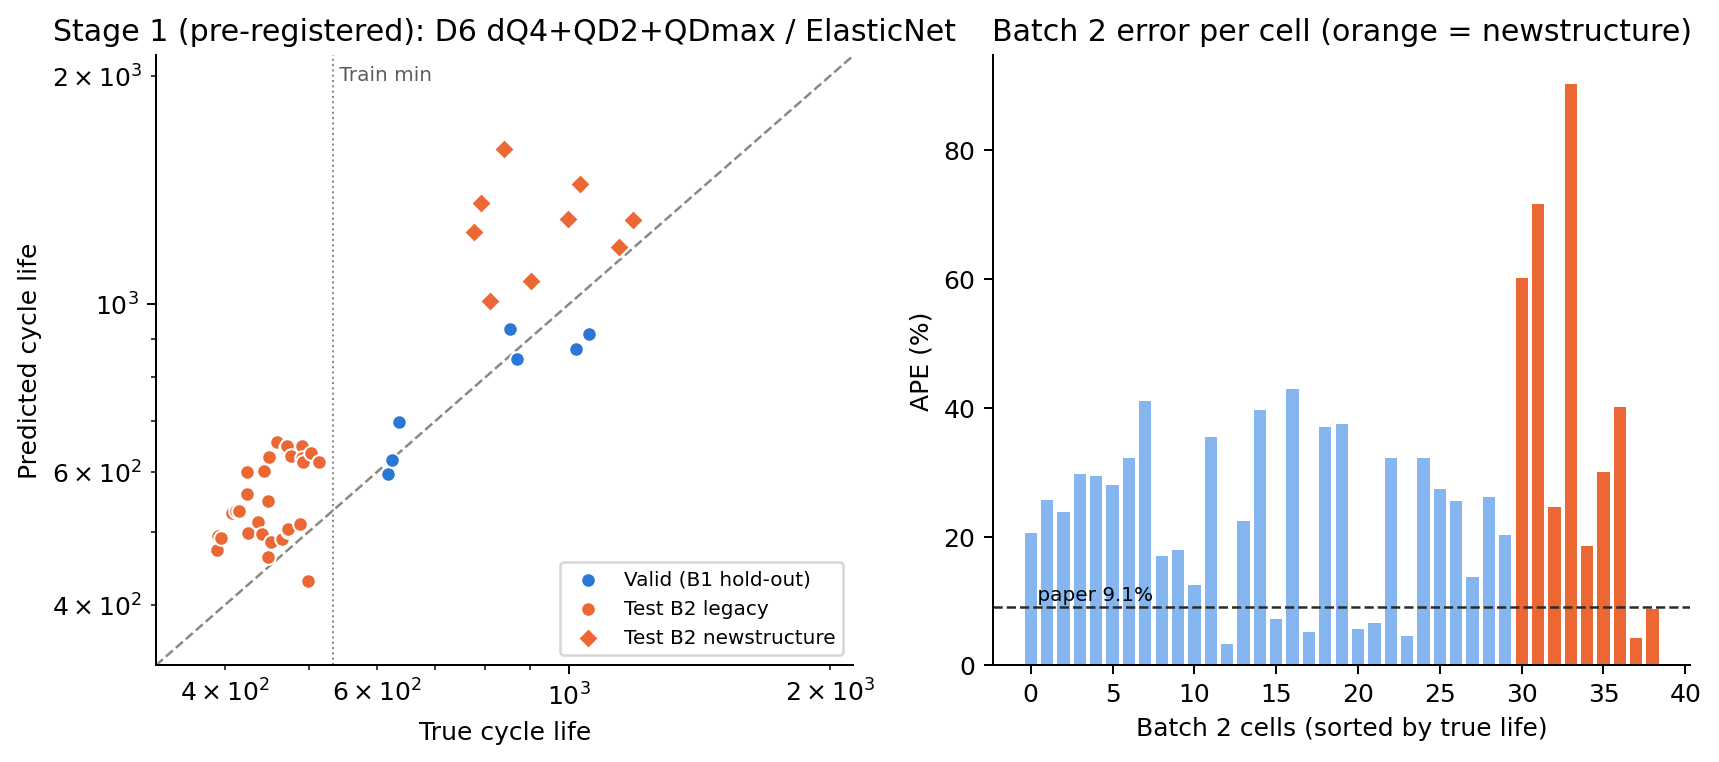

In [6]:
P = pd.read_csv(ROOT / "results" / "stage1" / "predictions.csv"); T = P[P.split == "Test(B2)"].copy()
T["signed_%"] = (T.pred - T.cycle_life) / T.cycle_life * 100
print(f"예측값 범위 {T.pred.min():.0f}~{T.pred.max():.0f} (Train 최소 {b1.cycle_life.min():.0f}) | 실제보다 길게 예측한 셀 {(T['signed_%'] > 0).mean():.0%}")
T["life_bucket"] = pd.cut(T.cycle_life, [0, 450, 550, 800, 1300], labels=["<450", "450-550", "550-800", ">800"])
display(T.groupby("life_bucket", observed=True).agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
display(T.groupby("new_structure").agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
display(T.sort_values("ape", ascending=False).head(8)[["cell_id", "policy", "cycle_life", "pred", "ape"]].round(1))
lo, hi = b1.cycle_life.min(), b1.cycle_life.max()
T3 = P[P.split == "Test(B3)"].copy(); T3["signed_%"] = (T3.pred - T3.cycle_life) / T3.cycle_life * 100
for nm, t in (("Batch 2", T), ("Batch 3", T3)):
    t["Train 수명 범위"] = np.where(t.cycle_life < lo, "범위 아래", np.where(t.cycle_life > hi, "범위 위", "범위 안"))
    print(f"[{nm}] 전체 MAPE {t.ape.mean():.1f}% (n={len(t)}), 평균 편향 {t['signed_%'].mean():+.1f}%")
    display(t.groupby("Train 수명 범위").agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
from IPython.display import Image; display(Image(str(FIG / "pred_vs_true_stage1.png")))